In [1]:
import pandas as pd

In [2]:
# read knowledge_bay_content excel in ../../content
df = pd.read_excel('../../content/knowledge_bay_content_local.xlsx', sheet_name='Publications')
df.head()

,Conference ID,City,Country,Lat,Lng,Conference Name,Date,Paper ID,Paper Title,Topic,Authors,Abstract,Year,DOI,Keywords
0,WACV,"Tucson, Arizona",USA,32.2217° N,110.9265° W,Winter Conference on Applications of Computer ...,NaN,p1,SHIP: Structural Hierarchies for Instance-depe...,Machine Learning,"Tushar Kadam, Utkarsh Mishra, Aakarsh Malhotra",NaN,2025,NaN,NaN
1,IJCAI,Montreal,Canada,45.5017° N,73.5673° W,International Joint Conference on Artificial I...,NaN,p2,SALE-MLP: Structure Aware Latent Embeddings fo...,Graph Learning,"Harsh Pal, Sarthak Malik, Rajat Patel, Aakarsh...",NaN,2025,NaN,NaN
2,SIGKDD,Toronto,Canada,43.6532° N,79.3832° W,ACM SIGKDD Conference on Knowledge Discovery a...,NaN,p3,Tag2M- A Task-Agnostic Knowledge Distillation ...,Graph Learning,"Ram Ganesh V, Ayush Singh, Aditi Rai, Harsh Pa...",NaN,2025,NaN,NaN
3,ECML PKDD,Porto,Portugal,41.1579° N,8.6291° W,European Conference on Machine Learning and Pr...,NaN,p4,Prodem: Proactive Detection of Model Degradati...,Applications in finance,"Akshay Sethi, Priyanshi Gupta, Sparsh Kansotia...",NaN,2025,NaN,NaN
4,ECAI,Bologna,Italy,44.4949° N,11.3426° E,European Conference on Artificial Intelligence...,NaN,p5,FairFusion: Debiasing Diffusion Models for Fai...,Responsible AI,"Ruma Roy, Darshika Tiwari, and Anubha Pandey",NaN,2025,NaN,NaN


In [3]:
df['Conference ID'].unique()

array(['WACV', 'IJCAI', 'SIGKDD', 'ECML PKDD', 'ECAI', 'PAIS', 'CIKM',
       'ICAIF', 'CODS', 'AAAI', 'ICPR', 'LOG', 'IJCNN', 'PKDD', 'ICDM',
       'AI4TS', 'IntelliSys', 'PAKDD', 'ICONIP', 'IEEE', 'ICMLA', 'ADMA',
       'ICANN', 'FLAIRS', 'ACM', 'NEURIPS', 'ICDMW', 'ICDAR', 'ICLR',
       'ITCC', 'CNIOT', 'Springer', 'ACL', 'GHCI'], dtype=object)

In [6]:
df.shape

(84, 15)

In [9]:
df[['Conference ID','Year']].drop_duplicates().shape

(53, 2)

In [161]:
# extract bracket names from conference names
import re
def extract_bracket(name):
    match = re.search(r'\((.*?)\)', name)
    return match.group(1) if match else None
df['Conference Bracket'] = df['Conference Name'].apply(extract_bracket)
df[['Conference Name', 'Conference Bracket']].head()

,Conference Name,Conference Bracket
0,Winter Conference on Applications of Computer ...,WACV
1,International Joint Conference on Artificial I...,IJCAI
2,ACM SIGKDD Conference on Knowledge Discovery a...,KDD
3,European Conference on Machine Learning and Pr...,ECML PKDD
4,European Conference on Artificial Intelligence...,ECAI


In [162]:
df['Conference Bracket'].nunique()

50

In [163]:
df['Conference Bracket'].sort_values().unique()

array(['ACL', 'ACM', 'ACM CODS-COMAD', 'ADMA', 'ADS', 'AI4TS',
       'Applied Data Science Hackathon', 'CIKM', 'CIKM 2024', 'CIKM Full',
       'CIKM Short', 'CODS', 'CODS COMAD 2024', 'ECAI', 'ECML PKDD',
       'ECML PKDD 2024', 'ECML-PKDD', 'ECML-PKDD 2023', 'FLAIRS',
       'FUSION', 'FinNLP', 'GCLR @ AAAI 2024', 'GHCI', 'ICAIF', 'ICANN',
       'ICDAR', 'ICDM 2023', 'ICDMW', 'ICLR', 'ICMLA', 'ICONIP',
       'ICPR 2024', 'IJCAI', 'IJCNN', 'IJCNN 2023', 'ITCC', 'IntelliSys',
       'KDD', 'KDD Workshop', 'LOG', 'LoG', 'MiLeTS', 'NeurIPS', 'PAIS',
       'PAKDD-22', 'PKDD 2023', 'SIKDD 2024', 'Springer', 'WACV',
       'WACV 2025'], dtype=object)

In [164]:
conference_mapper = {
    'CIKM': ['CIKM', 'CIKM 2024', 'CIKM Full', 'CIKM Short'],
    'CODS-COMAD': ['ACM CODS-COMAD', 'CODS', 'CODS COMAD 2024'],
    'ECML-PKDD': ['ECML-PKDD 2023', 'ECML PKDD', 'ECML PKDD 2024', 'ECML-PKDD', 
                  'European Conference on Machine Learning and Principles and Practice of Knowledge Discovery in Databases',
                  'Principles and Practice of Knowledge Discovery in Databases'],
    'IJCNN': ['IJCNN', 'IJCNN 2023', 'International Joint Conference on Neural Networks'],
    'WACV': ['WACV', 'WACV 2025'],
    'ICPR': ['International Conference on Pattern Recognition'],
    'SIKDD': ['SIKDD 2024', 'SIKDD'],
    'GCLR @ AAAI': ['GCLR @ AAAI 2024', 'GCLR @ AAAI'],
    'PAKDD': ['PAKDD-22', 'PAKDD',],
    'KDD': ['KDD Workshop', 'KDD'],
    'LOG': ['LOG', 'LoG'],
    'ICPR': ['ICPR', 'ICPR 2024'],
    'PKDD': ['PKDD', 'PKDD 2023'],
}

In [165]:
df['Conference ID'] = df['Conference Bracket'].map(lambda x: next((key for key, values in conference_mapper.items() if x in values), x))

In [166]:
df['Conference ID'].nunique()

38

In [167]:
df['Conference ID'].sort_values().unique()

array(['ACL', 'ACM', 'ADMA', 'ADS', 'AI4TS',
       'Applied Data Science Hackathon', 'CIKM', 'CODS-COMAD', 'ECAI',
       'ECML-PKDD', 'FLAIRS', 'FUSION', 'FinNLP', 'GCLR @ AAAI', 'GHCI',
       'ICAIF', 'ICANN', 'ICDAR', 'ICDM 2023', 'ICDMW', 'ICLR', 'ICMLA',
       'ICONIP', 'ICPR', 'IJCAI', 'IJCNN', 'ITCC', 'IntelliSys', 'KDD',
       'LOG', 'MiLeTS', 'NeurIPS', 'PAIS', 'PAKDD', 'PKDD', 'SIKDD',
       'Springer', 'WACV'], dtype=object)

In [168]:
# drop column 'Conference Bracket'
df.drop('Conference Bracket', axis=1, inplace=True)

In [169]:
import re

def convert_to_decimal(coord):
    """
    Convert coordinate from decimal deg N/S/E/W format to decimal.
    
    Examples:
        '32.2217° N' -> 32.2217
        '110.9265° W' -> -110.9265
    """
    if not isinstance(coord, str):
        return None
    
    try:
        # Extract the numeric value and direction
        match = re.search(r'([\d.]+)\s*°?\s*([NSEW])', coord.strip())
        
        if not match:
            return None
        
        degrees = float(match.group(1))
        direction = match.group(2).upper()
        
        # Make negative for South and West
        if direction in ['S', 'W']:
            degrees = -degrees
            
        return round(degrees, 6)
    except (ValueError, AttributeError):
        return None

In [170]:
df.columns

Index(['Conference ID', 'City', 'Country', 'Lat', 'Lng', 'Conference Name',
       'Date', 'Paper ID', 'Paper Title', 'Topic', 'Authors', 'Abstract',
       'Year', 'DOI', 'Keywords'],
      dtype='object')

In [171]:
df[['Lat', 'Lng']]

,Lat,Lng
0,32.2217° N,110.9265° W
1,45.5017° N,73.5673° W
2,43.6532° N,79.3832° W
3,41.1579° N,8.6291° W
4,44.4949° N,11.3426° E
...,...,...
79,52.5200° N,13.4050° E
80,47.6062° N,122.3321° W
81,12.9716° N,77.5946° E
82,53.2707° N,9.0568° W


In [174]:
df[['Lat', 'Lng']]

,Lat,Lng
0,32.2217,-110.9265
1,45.5017,-73.5673
2,43.6532,-79.3832
3,41.1579,-8.6291
4,44.4949,11.3426
...,...,...
79,52.5200,13.4050
80,47.6062,-122.3321
81,12.9716,77.5946
82,53.2707,-9.0568


In [173]:
df['Lat'] = df['Lat'].apply(convert_to_decimal)
df['Lng'] = df['Lng'].apply(convert_to_decimal)

In [175]:
# save back to same excel
with pd.ExcelWriter('../../content/knowledge_bay_content.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df.to_excel(writer, sheet_name='Publications', index=False)

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def make_symmetric_slots(
    count,
    angle_const=None,
    max_r=1.0,
    radial_power=0.5
):
    """
    Generate symmetric 2D points inside a unit circle.

    Parameters:
        count (int): number of points
        angle_const (float): angular increment (default = golden angle)
        max_r (float): max radius
        radial_power (float): controls radial distribution
                              0.5 = area-balanced (sqrt)
                              1.0 = linear
                              <0.5 = denser centre
                              >0.5 = denser edge
    """

    if count <= 0:
        return np.array([])

    if count == 1:
        return np.array([[0.0, 0.0]])

    if angle_const is None:
        angle_const = np.pi * (3 - np.sqrt(5))  # proper golden angle

    points = []

    is_odd = count % 2 == 1
    if is_odd:
        points.append((0.0, 0.0))

    pair_count = count // 2

    for i in range(pair_count):
        t = i + 1
        r = (t / (pair_count + 1)) ** radial_power * max_r
        a = t * angle_const

        ux = r * np.cos(a)
        uy = r * np.sin(a)

        points.append((ux, uy))
        points.append((-ux, -uy))

    return np.array(points[:count])


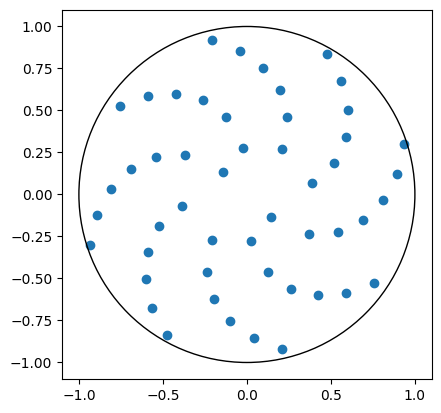

In [2]:
def plot_points(points):
    plt.figure()
    plt.scatter(points[:, 0], points[:, 1])
    circle = plt.Circle((0, 0), 1, fill=False)
    plt.gca().add_artist(circle)
    plt.gca().set_aspect('equal', 'box')
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.show()


pts = make_symmetric_slots(50)
plot_points(pts)


In [3]:
!pip install ffmpeg-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ffmpeg-python]0m [ffmpeg-python]


In [6]:
import ffmpeg

(
    ffmpeg
    .input("assets/videos/0. MC Facts.mp4")
    .output("assets/videos/0. MC Facts.mkv", c="copy")
    .run(cmd="/Users/e131770/Downloads/ffmpeg")
)

Error: ffmpeg error (see stderr output for detail)